In [1]:
!pip install tensorflow-model-optimization


# ============================================================
# IMPORTS
# ============================================================
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.metrics import confusion_matrix, classification_report
import itertools
import tensorflow as tf
from tensorflow.keras import layers, Model

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 242.5/242.5 kB 6.4 MB/s eta 0:00:00


2025-11-22 19:08:07.298240: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1763838487.538077      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1763838487.616573      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

## **Dataset Configuration**

In [2]:
IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 40

data_dir = "/kaggle/input/plant-disease-expert/Image Data base/Image Data base"   

# --------------------------------------------------------------
# FIRST SPLIT → TRAIN (70%) + TEMP (30%)
# --------------------------------------------------------------
train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.30,
    subset="training",
    seed=42,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE
)

temp_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.30,
    subset="validation",
    seed=42,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE
)

# --------------------------------------------------------------
# SECOND SPLIT → TEMP → VAL (15%) + TEST (15%)
# --------------------------------------------------------------
val_ds = temp_ds.take(int(len(temp_ds) * 0.5))
test_ds = temp_ds.skip(int(len(temp_ds) * 0.5))

class_names = train_ds.class_names
num_classes = len(class_names)

print("Classes:", class_names)
print("Train batches:", len(train_ds))
print("Val batches:", len(val_ds))
print("Test batches:", len(test_ds))


Found 199665 files belonging to 58 classes.
Using 139766 files for training.


I0000 00:00:1763838652.788648      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1763838652.789376      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 199665 files belonging to 58 classes.
Using 59899 files for validation.
Classes: ['Apple Apple scab', 'Apple Black rot', 'Apple Cedar apple rust', 'Apple healthy', 'Bacterial leaf blight in rice leaf', 'Blight in corn Leaf', 'Blueberry healthy', 'Brown spot in rice leaf', 'Cercospora leaf spot', 'Cherry (including sour) Powdery mildew', 'Cherry (including_sour) healthy', 'Common Rust in corn Leaf', 'Corn (maize) healthy', 'Garlic', 'Grape Black rot', 'Grape Esca Black Measles', 'Grape Leaf blight Isariopsis Leaf Spot', 'Grape healthy', 'Gray Leaf Spot in corn Leaf', 'Leaf smut in rice leaf', 'Nitrogen deficiency in plant', 'Orange Haunglongbing Citrus greening', 'Peach healthy', 'Pepper bell Bacterial spot', 'Pepper bell healthy', 'Potato Early blight', 'Potato Late blight', 'Potato healthy', 'Raspberry healthy', 'Sogatella rice', 'Soybean healthy', 'Strawberry Leaf scorch', 'Strawberry healthy', 'Tomato Bacterial spot', 'Tomato Early blight', 'Tomato Late blight', 'Tomato Leaf M

## **EDA — Class Names & Image Counts**

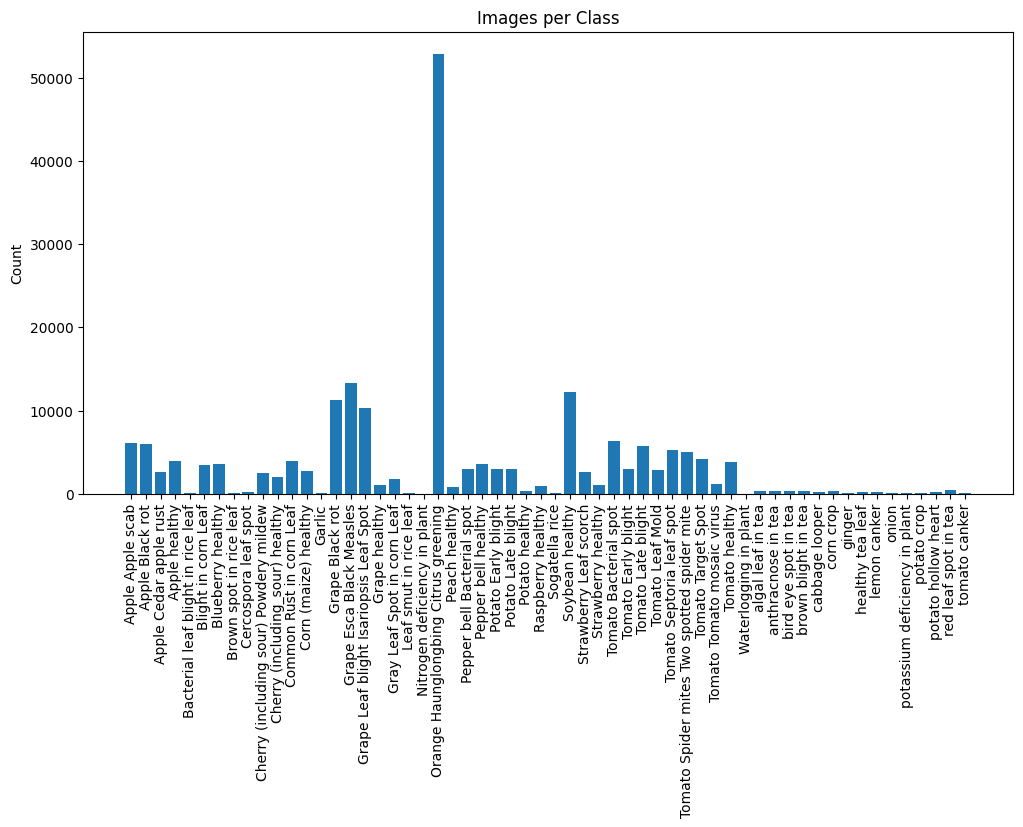

In [3]:
class_counts = {cls: len(os.listdir(os.path.join(data_dir, cls))) 
                for cls in class_names}

plt.figure(figsize=(12,6))
plt.bar(class_counts.keys(), class_counts.values())
plt.xticks(rotation=90)
plt.title("Images per Class")
plt.ylabel("Count")
plt.show()


### **EDA — Plot Class Distribution**

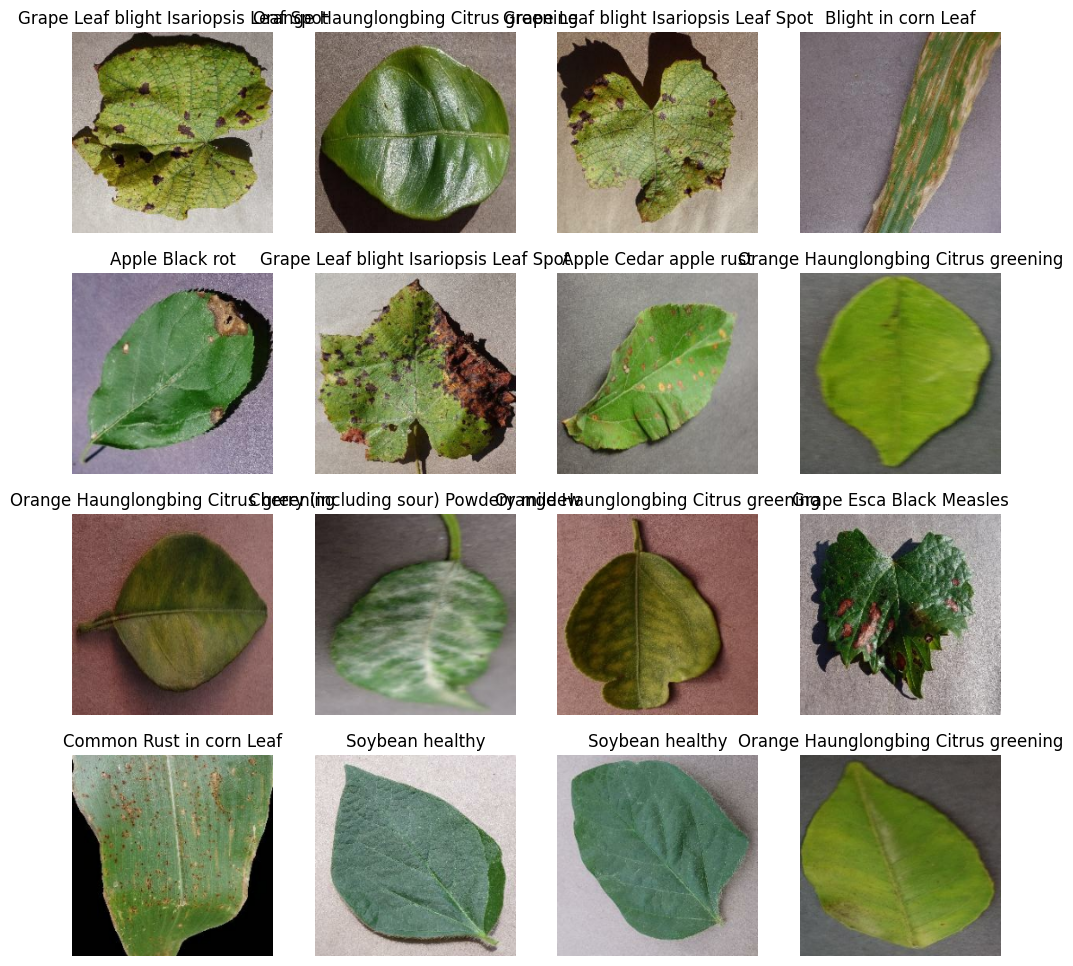

In [4]:
plt.figure(figsize=(12, 12))
for images, labels in train_ds.take(1):
    for i in range(16):
        ax = plt.subplot(4, 4, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")


## **Prepare Dataset for Training**

In [5]:
normalization_layer = layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds   = val_ds.map(lambda x, y: (normalization_layer(x), y))
test_ds  = test_ds.map(lambda x, y: (normalization_layer(x), y))

train_ds = train_ds.prefetch(tf.data.AUTOTUNE)
val_ds   = val_ds.prefetch(tf.data.AUTOTUNE)
test_ds  = test_ds.prefetch(tf.data.AUTOTUNE)


## **Build the Efficient-CNN (State-of-the-art custom architecture)**

In [6]:
# -----------------------------
#   Multi-head self-attention
# -----------------------------
def transformer_block(x, num_heads, key_dim, mlp_dim):
    attn = layers.MultiHeadAttention(num_heads=num_heads, key_dim=key_dim)(x, x)
    x = layers.Add()([x, attn])
    x = layers.LayerNormalization()(x)

    # Feed-forward
    ff = layers.Dense(mlp_dim, activation="relu")(x)
    ff = layers.Dense(x.shape[-1])(ff)
    x = layers.Add()([x, ff])
    x = layers.LayerNormalization()(x)

    return x


# -----------------------------
#   Build ConvTransformerNet
# -----------------------------
def build_conv_transformer_net(img_size, num_classes):
    inputs = layers.Input((img_size, img_size, 3))

    # ---- CNN Stage ----
    x = layers.Conv2D(32, 3, padding="same", activation="relu")(inputs)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(64, 3, padding="same", activation="relu")(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(128, 3, padding="same", activation="relu")(x)
    x = layers.MaxPooling2D()(x)

    # Flatten spatial dims for Transformer
    H, W = x.shape[1], x.shape[2]
    x = layers.Reshape((H * W, 128))(x)

    # ---- Transformer Stage ----
    x = transformer_block(x, num_heads=4, key_dim=64, mlp_dim=256)
    x = transformer_block(x, num_heads=4, key_dim=64, mlp_dim=256)

    # ---- Classification Head ----
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(0.3)(x)

    outputs = layers.Dense(num_classes, activation="softmax")(x)

    return Model(inputs, outputs)


## **Compile and Model Summary**

In [7]:
model = build_conv_transformer_net(IMG_SIZE, num_classes)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0002),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 224, 224,  │        896 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 112, 112,  │          0 │ conv2d[0][0]      │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 112, 112,  │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 56, 56,    │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 56, 56,    │     73,856 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 28, 28,    │          0 │ conv2d_2[0][0]    │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 784, 128)  │          0 │ max_pooling2d_2[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 784, 128)  │    131,968 │ reshape[0][0],    │
│ (MultiHeadAttentio… │                   │            │ reshape[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 784, 128)  │          0 │ reshape[0][0],    │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 784, 128)  │        256 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 784, 256)  │     33,024 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 784, 128)  │     32,896 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 784, 128)  │          0 │ layer_normalizat… │
│                     │                   │            │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 784, 128)  │        256 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 784, 128)  │    131,968 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 784, 128)  │          0 │ layer_normalizat… │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 784, 128)  │        256 │ add_2[0][0]     

 Total params: 537,978 (2.05 MB)

 Trainable params: 537,978 (2.05 MB)

 Non-trainable params: 0 (0.00 B)

## **Train the Model**

In [8]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)


Epoch 1/40


I0000 00:00:1763838703.014058      73 service.cc:148] XLA service 0x7af2cc009ff0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1763838703.014953      73 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1763838703.014972      73 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1763838704.045111      73 cuda_dnn.cc:529] Loaded cuDNN version 90300
I0000 00:00:1763838712.206641      73 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


4368/4368 ━━━━━━━━━━━━━━━━━━━━ 761s 171ms/step - accuracy: 0.6524 - loss: 1.3379 - val_accuracy: 0.9384 - val_loss: 0.2051
Epoch 2/40
4368/4368 ━━━━━━━━━━━━━━━━━━━━ 747s 171ms/step - accuracy: 0.9291 - loss: 0.2241 - val_accuracy: 0.9595 - val_loss: 0.1280
Epoch 3/40
4368/4368 ━━━━━━━━━━━━━━━━━━━━ 749s 172ms/step - accuracy: 0.9536 - loss: 0.1420 - val_accuracy: 0.9637 - val_loss: 0.1090
Epoch 4/40
4368/4368 ━━━━━━━━━━━━━━━━━━━━ 750s 172ms/step - accuracy: 0.9652 - loss: 0.1048 - val_accuracy: 0.9718 - val_loss: 0.0799
Epoch 5/40
4368/4368 ━━━━━━━━━━━━━━━━━━━━ 750s 172ms/step - accuracy: 0.9699 - loss: 0.0882 - val_accuracy: 0.9806 - val_loss: 0.0606
Epoch 6/40
4368/4368 ━━━━━━━━━━━━━━━━━━━━ 748s 171ms/step - accuracy: 0.9764 - loss: 0.0705 - val_accuracy: 0.9786 - val_loss: 0.0611
Epoch 7/40
4368/4368 ━━━━━━━━━━━━━━━━━━━━ 748s 171ms/step - accuracy: 0.9779 - loss: 0.0645 - val_accuracy: 0.9802 - val_loss: 0.0584
Epoch 8/40
4368/4368 ━━━━━━━━━━━━━━━━━━━━ 750s 172ms/step - accuracy: 0.9

## **Plot Training Accuracy & Loss**

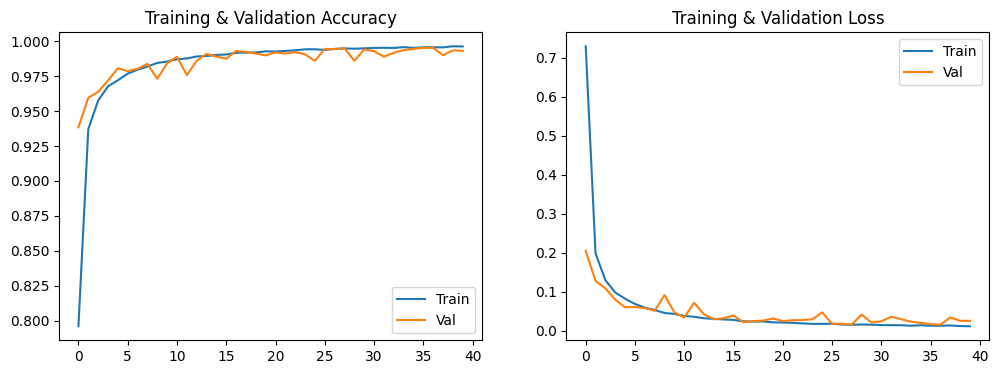

In [9]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Training & Validation Accuracy")
plt.legend(['Train', 'Val'])

plt.subplot(1,2,2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Training & Validation Loss")
plt.legend(['Train', 'Val'])

plt.show()


## **Predictions for Confusion Matrix**

In [10]:
test_loss, test_acc = model.evaluate(test_ds)
print("TEST ACCURACY:", test_acc)


936/936 ━━━━━━━━━━━━━━━━━━━━ 85s 71ms/step - accuracy: 0.9936 - loss: 0.0246
TEST ACCURACY: 0.9930210113525391


In [11]:
y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images)
    preds = np.argmax(preds, axis=1)
    y_true.extend(labels.numpy())
    y_pred.extend(preds)

y_true = np.array(y_true)
y_pred = np.array(y_pred)


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━

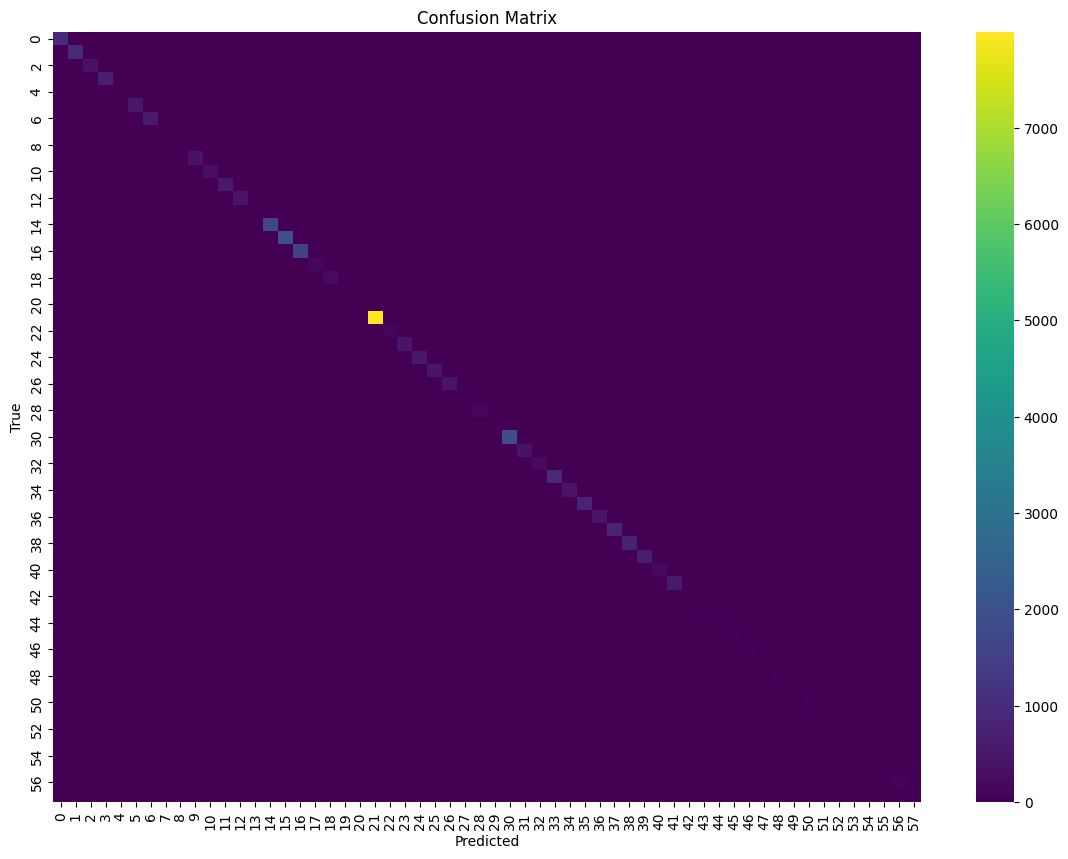

In [12]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(14, 10))
sns.heatmap(cm, annot=False, cmap="viridis")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()


In [13]:
print(classification_report(y_true, y_pred, target_names=class_names))


                                             precision    recall  f1-score   support

                           Apple Apple scab       1.00      1.00      1.00       955
                            Apple Black rot       1.00      1.00      1.00       925
                     Apple Cedar apple rust       1.00      1.00      1.00       372
                              Apple healthy       0.96      1.00      0.98       660
         Bacterial leaf blight in rice leaf       1.00      0.94      0.97        18
                        Blight in corn Leaf       0.94      0.96      0.95       502
                          Blueberry healthy       1.00      1.00      1.00       554
                    Brown spot in rice leaf       0.77      0.83      0.80        12
                       Cercospora leaf spot       0.82      0.82      0.82        38
     Cherry (including sour) Powdery mildew       1.00      1.00      1.00       394
            Cherry (including_sour) healthy       0.99      0.99

## **Predictions for Confusion Matrix**

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step


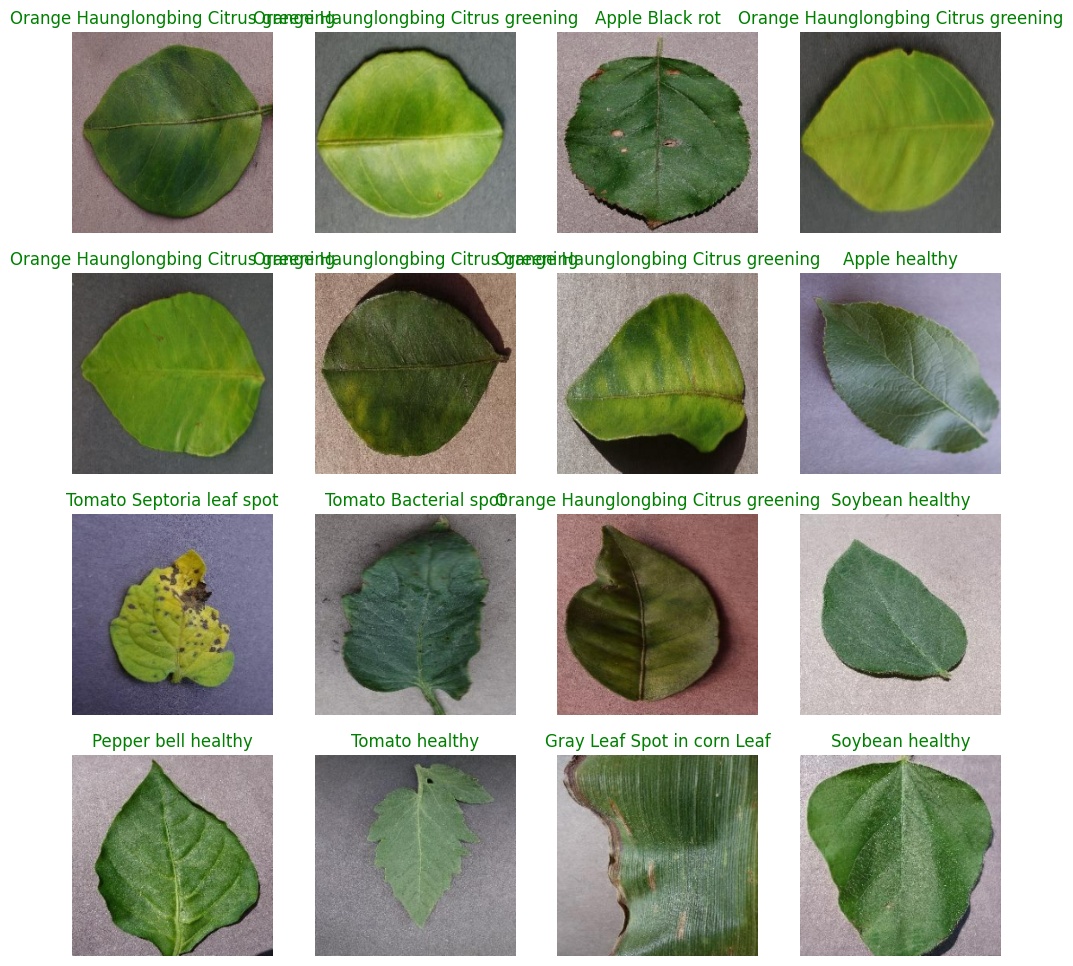

In [14]:
plt.figure(figsize=(12,12))

for images, labels in test_ds.take(1):
    preds = model.predict(images)
    preds = np.argmax(preds, axis=1)

    for i in range(16):
        ax = plt.subplot(4, 4, i + 1)
        plt.imshow(images[i].numpy())
        true_label = class_names[labels[i]]
        predicted = class_names[preds[i]]
        color = "green" if true_label == predicted else "red"
        plt.title(f"{predicted}", color=color)
        plt.axis("off")


In [15]:
model.save("Plaintify_diseases_classifier_model.keras")
print("Model is Saved")

Model is Saved


In [16]:
class_names

['Apple Apple scab',
 'Apple Black rot',
 'Apple Cedar apple rust',
 'Apple healthy',
 'Bacterial leaf blight in rice leaf',
 'Blight in corn Leaf',
 'Blueberry healthy',
 'Brown spot in rice leaf',
 'Cercospora leaf spot',
 'Cherry (including sour) Powdery mildew',
 'Cherry (including_sour) healthy',
 'Common Rust in corn Leaf',
 'Corn (maize) healthy',
 'Garlic',
 'Grape Black rot',
 'Grape Esca Black Measles',
 'Grape Leaf blight Isariopsis Leaf Spot',
 'Grape healthy',
 'Gray Leaf Spot in corn Leaf',
 'Leaf smut in rice leaf',
 'Nitrogen deficiency in plant',
 'Orange Haunglongbing Citrus greening',
 'Peach healthy',
 'Pepper bell Bacterial spot',
 'Pepper bell healthy',
 'Potato Early blight',
 'Potato Late blight',
 'Potato healthy',
 'Raspberry healthy',
 'Sogatella rice',
 'Soybean healthy',
 'Strawberry Leaf scorch',
 'Strawberry healthy',
 'Tomato Bacterial spot',
 'Tomato Early blight',
 'Tomato Late blight',
 'Tomato Leaf Mold',
 'Tomato Septoria leaf spot',
 'Tomato Spider

In [17]:
import pandas as pd

history_df = pd.DataFrame(history.history)

# -----------------------------
# Save training history as CSV
# -----------------------------
csv_filename = "training_history.csv"
history_df.to_csv(csv_filename, index=False)

print(f"Training history saved to: {csv_filename}")
history_df.head()

Training history saved to: training_history.csv


,accuracy,loss,val_accuracy,val_loss
0,0.795923,0.729557,0.938401,0.205093
1,0.937059,0.198475,0.959468,0.128033
2,0.957479,0.129783,0.963709,0.109000
3,0.967696,0.098412,0.971822,0.079875
4,0.972032,0.082270,0.980636,0.060639
